## Lesson 5: Classification


### Environment Setup

Run this once. If you already have these installed, this will just verify versions. Internet required for first run.


In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
!pip install --quiet numpy pandas scikit-learn matplotlib seaborn kagglehub ipympl imbalanced-learn

import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import kagglehub
import os

print('numpy:', np.__version__)
print('pandas:', pd.__version__)
print('sklearn:', sklearn.__version__)


numpy: 2.0.2
pandas: 2.2.2
sklearn: 1.6.1


In [3]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

def evaluate_model(model, X_test, y_test, model_name, class_names=['No Default', 'Default']):
    """
    Evaluates a classification model by printing a classification report
    and displaying a confusion matrix.
    """
    print(f"\n--- {model_name} Evaluation ---")
    y_pred = model.predict(X_test)

    # Print the classification report
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=class_names))

    # --- Confusion Matrix ---
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix ({model_name})")
    plt.show()

# Helper function to plot decision boundaries
def plot_decision_boundaries(X, y, model, title,
                             feature_names=['X1', 'X2'], class_names=['Class 1', 'Class 2', 'Class 3'],
                             control_column=None, control_value=0, ax=None, figsize=(12, 6), samples=300,
                             x1_padding=0, x2_padding=0,
                             X_scaler=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    x1_range = np.linspace(X[feature_names[0]].min() - x1_padding, X[feature_names[0]].max() + x1_padding, samples)
    x2_range = np.linspace(X[feature_names[1]].min() - x2_padding, X[feature_names[1]].max() + x2_padding, samples)
    x1_mesh, x2_mesh = np.meshgrid(x1_range, x2_range)

    if control_column is not None:
        predict_vals = np.c_[np.full(x1_mesh.size, control_value), x1_mesh.ravel(), x2_mesh.ravel()]
    else:
        predict_vals = np.c_[x1_mesh.ravel(), x2_mesh.ravel()]

    if X_scaler is not None:
        predict_vals = X_scaler.transform(predict_vals)

    # Predict on the meshgrid
    Z = model.predict(predict_vals)
    Z = Z.reshape(x1_mesh.shape)

    # Plot the contour and training examples
    ax.contourf(x1_mesh, x2_mesh, Z, alpha=0.4, cmap='RdYlGn')
    scatter = ax.scatter(X[feature_names[0]], X[feature_names[1]], c=y, s=20, edgecolor='k', cmap='RdYlGn')

    ax.set_title(title)
    ax.set_xlabel(feature_names[0])
    ax.set_ylabel(feature_names[1])
    ax.legend(handles=scatter.legend_elements()[0], labels=class_names)

    return ax

## 1. What is Classification?

### 1.1. Definition

The linear regression model discussed in the previous week assumes that the response variable **Y** is _quantitative_. But what if we want to predict, say, eye colors, which are _qualitative_ (also called _categorical_)?

Predicting qualitative features is a process known as **classification**. For a given observation, a **classification model** (or **classifier**) is responsible for assigning it to a category, or class.

Just as in the regression setting, classification requires a set of observations $(x_1,y_1),...,(x_n,y_n)$ that can be split for model training and testing. $x_i$, the observation to be classified, can have any shape - it can be, for example, a table row or an image. $y_i$ is its respective label, or class - examples of labels include _'cat'/'dog', or 'spam'/'not spam'_.

There are many possible classifiers that one might use for predicting categorical features. In this week, we will discuss some widely-used models: **logistic regression, decision trees, random forests, and support vector machines (SVMs)**.

### 1.2. Types of Classification

The primary types of classification in machine learning are the following:

- **Binary Classification**: A model predicts an output that bleongs to one of two possible classes or categories. **Examples**: spam or not spam, sick or healthy.

- **Multi-Class Classification**: A model assigns an item to one of several categories, where the categories are mutually exclusive. **Examples**: identifying digits (0, 1, 2, ...), identifying dog species.

- **Multi-Label Classification**: A model assigns an item to multiple non-exclusive categories simultaneously. **Examples**: tagging articles, tagging images.

### 1.3. Why Not Use Linear Regression?

It's tempting, especially when there are only two classes, to simply use a linear regression model that classifies based on a certain threshold. For example, say we would code a spam-filtering prediction as such:

$$
Y=
\begin{cases}
0 \text{ if} \textbf{ not spam};\\
1 \text{ if} \textbf{ spam}.\\
\end{cases}
$$

We could then fit a linear regression to this binary response and predict $\textbf{spam}$ if $\hat{Y} > 0.5$ and $\textbf{not spam}$ otherwise.

But what if there are more than two classes? What if we want to classify patients suffering from 3 different diseases - diabetes, stroke, or seizure? A similar encoding would look like so:

$$
Y=
\begin{cases}
1 \text{ if} \textbf{ diabetes};\\
2 \text{ if} \textbf{ stroke};\\
3 \text{ if} \textbf{ seizure}.\\
\end{cases}
$$

This coding would, unfortunately, induce a bias since the outcomes are ordered - this would somehow imply that the diabetes class is somehow "smaller" than the seizure one, with stroke between them. There is no reason why that would be the case, as every permutation of these classes would be valid.

Although we could think of certain cases where categories can be ordered, such as _small_, _medium_ and _large_, most problems encountered in the wild don't follow such patterns.

Another problem is that linear regression can output estimates that sit outside the $[0,1]$ interval, making them more difficult to interpret as probabilities. Thus, it is preferable to **use a classification method that is suited for qualitative response values**.

## 2. Our Dataset

### 2.1. Binary Classification - Credit Card Default

This week, we will illustrate classification using a simple **credit card default** dataset, with the following features:

- **student** - whether the customer is a student or not ($\text{Yes}/\text{No}$)

- **balance** - the customer's monthly credit card balance (float)

- **income** - the customer's yearly income (float)

- **default** - whether the customer has defaulted or not ($\text{Yes}/\text{No}$)

Here, we are interested in predicting whether an individual will default on his / her credit card payment ($Y$), based on the other available features ($X$).

In [4]:
# Download latest version
path = kagglehub.dataset_download("alukosayoenoch/credit-card-default-data")
dataset_path = "/".join((path, "Credit Card Default Data.csv"))
default_dataset = pd.read_csv(dataset_path)

Using Colab cache for faster access to the 'credit-card-default-data' dataset.


In [5]:
default_dataset['default'] = default_dataset['default'].map({'Yes': 1, 'No': 0})
default_dataset['student'] = default_dataset['student'].map({'Yes': 1, 'No': 0})
default_dataset.drop(columns=['Unnamed: 0'], inplace=True)
default_dataset.head()

,default,student,balance,income
0,0,0,729.526495,44361.625074
1,0,1,817.180407,12106.134700
2,0,0,1073.549164,31767.138947
3,0,0,529.250605,35704.493935
4,0,0,785.655883,38463.495879


Class Imbalance:
default
0    0.9667
1    0.0333
Name: proportion, dtype: float64


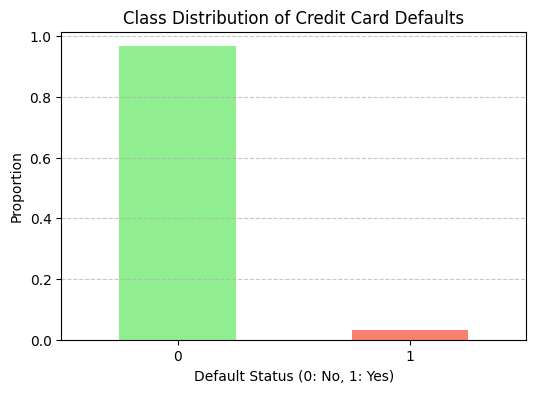

In [6]:
# Check for class imbalance
imbalance = default_dataset['default'].value_counts(normalize=True)
print("Class Imbalance:")
print(imbalance)

# Visualize the imbalance
plt.figure(figsize=(6, 4))
imbalance.plot(kind='bar', color=['lightgreen', 'salmon'])
plt.title('Class Distribution of Credit Card Defaults')
plt.xlabel('Default Status (0: No, 1: Yes)')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### The Challenge of Class Imbalance

As you can see from the plot above, our dataset is highly **imbalanced**. The "No Default" class (0) vastly outnumbers the "Default" class (1). This is a very common scenario in real-world datasets for problems like fraud detection, medical diagnosis, and, in our case, credit card defaults.

**Why is this a problem?**

If we're not careful, a machine learning model trained on an imbalanced dataset can be very misleading. The model can achieve a high accuracy score by simply predicting the majority class for all instances. For example, if 97% of our data is "No Default," a model that always predicts "No Default" will be 97% accurate. However, it will be completely useless for its intended purpose: identifying customers who *will* default.

A popular technique for dealing with class imbalance is **SMOTE**, which creates new synthetic samples from the minority class.

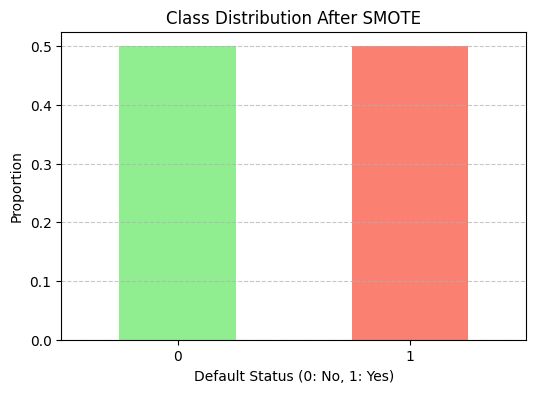

New class distribution:
default
0    9667
1    9667
Name: count, dtype: int64


In [7]:
from imblearn.over_sampling import SMOTE

# Separate features (X) and target (y)
X = default_dataset.drop('default', axis=1)
y = default_dataset['default']

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Visualize the balanced data
plt.figure(figsize=(6, 4))
y_resampled.value_counts(normalize=True).plot(kind='bar', color=['lightgreen', 'salmon'])
plt.title('Class Distribution After SMOTE')
plt.xlabel('Default Status (0: No, 1: Yes)')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("New class distribution:")
print(y_resampled.value_counts())

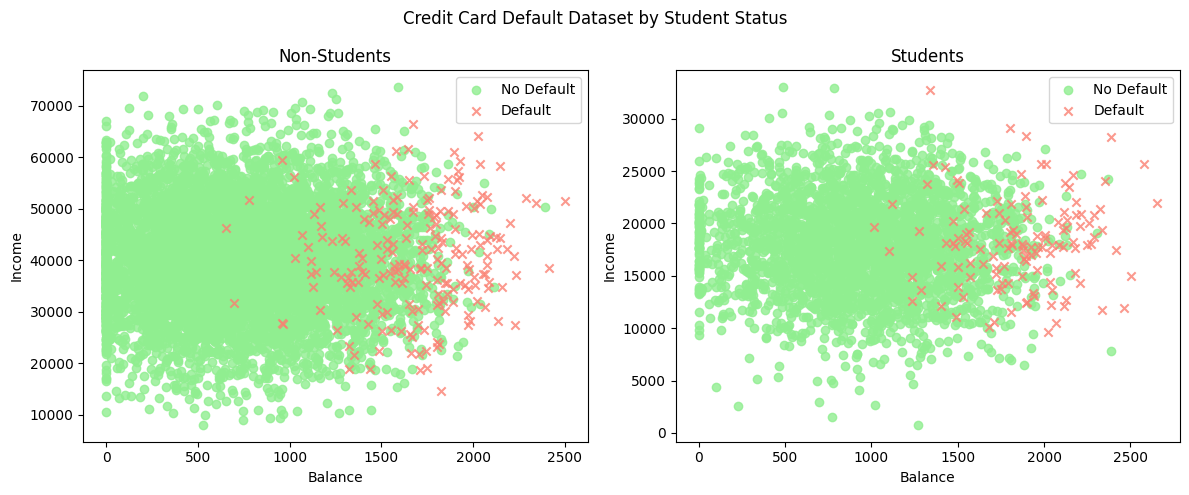

In [8]:
colors = {0: "lightgreen", 1: "salmon"}
markers = {0: "o", 1: "x"}

# Create subplots for students and non-students
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot for non-students (student = 0)
non_students = default_dataset[default_dataset['student'] == 0]
for cat, group in non_students.groupby('default'):
    ax1.scatter(
        group["balance"],
        group["income"],
        c=colors[cat],
        marker=markers[cat],
        alpha=0.8,
        label="No Default" if cat == 0 else "Default"
    )

ax1.legend()
ax1.set_xlabel("Balance")
ax1.set_ylabel("Income")
ax1.set_title("Non-Students")

# Plot for students (student = 1)
students = default_dataset[default_dataset['student'] == 1]
for cat, group in students.groupby('default'):
    ax2.scatter(
        group["balance"],
        group["income"],
        c=colors[cat],
        marker=markers[cat],
        alpha=0.8,
        label="No Default" if cat == 0 else "Default"
    )

ax2.legend()
ax2.set_xlabel("Balance")
ax2.set_ylabel("Income")
ax2.set_title("Students")

plt.suptitle("Credit Card Default Dataset by Student Status")
plt.tight_layout()
plt.show()

### Splitting the Data: Train and Test Sets

Before we start building any models, it's crucial to split our data into two parts:
-   **A training set:** This is what we'll use to teach our model.
-   **A testing set:** This will be used to evaluate the model's performance on data it has never seen before.

This practice is essential to avoid **overfitting**, where a model learns the training data too well but fails to generalize to new, unseen data. We'll use our resampled (SMOTE) data for this.

In [9]:
from sklearn.model_selection import train_test_split

# We use the resampled data for our train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.3, random_state=42, stratify=y_resampled
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("Training set class distribution:")
print(y_train.value_counts(normalize=True))
print("\nTesting set class distribution:")
print(y_test.value_counts(normalize=True))

Training set shape: (13533, 3)
Testing set shape: (5801, 3)
Training set class distribution:
default
1    0.500037
0    0.499963
Name: proportion, dtype: float64

Testing set class distribution:
default
0    0.500086
1    0.499914
Name: proportion, dtype: float64


### 2.2. Multi-Class Classification - Synthetic Dataset

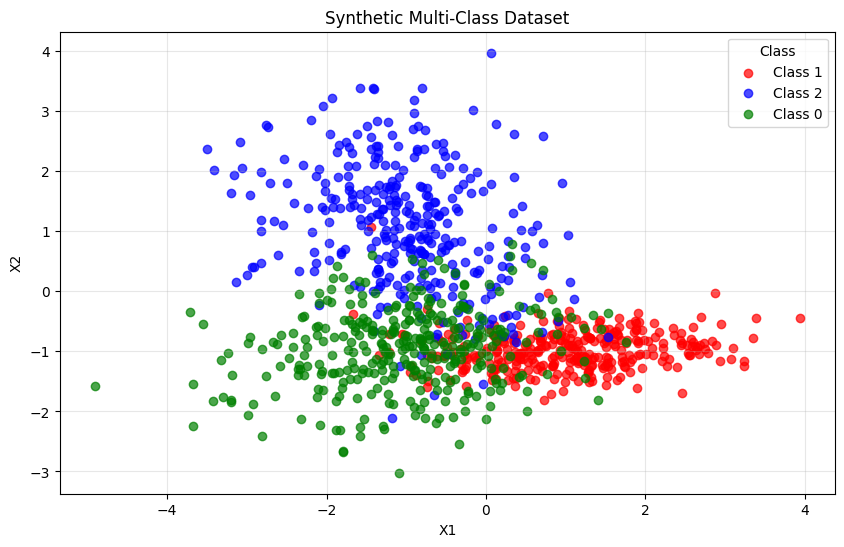

In [10]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

X_multiclass, y_multiclass = make_classification(n_samples=1000,
                                                 n_features=2, n_informative=2, n_redundant=0, n_repeated=0,
                                                 n_classes=3, n_clusters_per_class=1, random_state=20)
multiclass_dataset = pd.DataFrame(X_multiclass, columns=['X1', 'X2'])
multiclass_dataset['Class'] = y_multiclass

# Plot the classes
plt.figure(figsize=(10, 6))
colors = ['red', 'blue', 'green']
for i, class_label in enumerate(multiclass_dataset['Class'].unique()):
    class_data = multiclass_dataset[multiclass_dataset['Class'] == class_label]
    plt.scatter(class_data['X1'], class_data['X2'],
               c=colors[i], label=f'Class {class_label}', alpha=0.7)

plt.title('Synthetic Multi-Class Dataset')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend(title='Class')
plt.grid(True, alpha=0.3)
plt.show()

X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(multiclass_dataset[['X1', 'X2']],
                                                                            multiclass_dataset['Class'],
                                                                            test_size=0.2, random_state=42)

## 3. Logistic Regression

### 3.1. Definition

Logistic regression is a model designed to predict a **binary outcome** for an event based on the previous observations of a dataset. It does this by modeling the probability of the desired outcome (e.g. probability of default, probability of a disease).

In general, the probability of an outcome, written as $Pr(Y = 1 | X)$ or $p(X)$, will always range between 0 and 1. For example, for a data point $X$, $P(diabetes=1|X) = p(X) = 0.4$ means that the individual represented by $X$ has diabetes with a 40% probability.

Since logistic regression models the probability, this means that **logistic regression outputs must fall between 0 and 1**. This makes logistic regression a much better choice than linear regression for classification tasks, because linear regression can predict "probabilities" that go below 0 or above 1.

Since the logistic regression output represents this probability, we can set a **threshold** for determining the final predictions. Taking our default dataset as an example, we can predict $\text{default = Yes}$ for any individual for whom $p(X) > 0.5$, and $\text{default = No}$ otherwise.

### 3.2. The Logistic Function

Recall that the linear regression uses the following formula:

$$p(X)=\beta_0+\beta_1X$$

where $\beta_0$ is the intercept and $\beta_1$ is the slope. Logistic regression extends its linear counterpart by passing this linear equation through the logistic (sigmoid) function, which takes in any input and "squishes" it to fall inside the [0, 1] range. The sigmoid function is the following:

$$\sigma(x) = \frac{1}{1+e^{-x}}$$

The sigmoid function ensures that for large inputs, the output will get closer to, but not larger than, 1, while for low (even negative) inputs, the output will get close to, but never below, 0. By replacing $e^{-x}$ with $e^{-\beta_0+\beta_1X}$ and multiplying the numerator and denominator by ${e^{\beta_0+\beta_1X}}$, we arrive at the **logistic function**:

$$p(X)=\frac{e^{\beta_0+\beta_1X}}{1+e^{\beta_0+\beta_1X}}$$

For multiple predictors (e.g. $\text{balance}$, $\text{income}$, etc.), we can generalize the logistic function to use multiple predictors:

$$p(X) = \frac{e^{\beta_0+\beta_1X_1+...+\beta_pX_p}}{1+e^{\beta_0+\beta_1X_1+...+\beta_pX_p}}$$

Plotting out both models, we can see that linear regression produces a line, while logistic regression produces an S-shaped curve between 0 and 1:

<img src="https://i.imgur.com/vDouj2R.jpeg">

### 3.3. Fitting a Logistic Regression Model

In order to make useful predictions, we need to fit the logistic regression on our available training data. Because it models probabilities, logistic regression uses **maximum likelihood**, which implies seeking estimates of $\beta_0$ and $\beta_1$ such that model predictions correspond as closely as possible to the real default statuses.

Thus, optimal coefficients, when plugged in a model, would lead to predictions that are close to 1 for positive cases, and close to 0 for negative ones. The equation behind this is called the **likelihood function** and is as follows:

$$l(\beta_0, \beta_1)=\prod_{i:y_i=1}p(x_i)\prod_{i':y_i'=0}(1-p(x_i'))$$

The coefficients are chosen to maximize this likelihood function.

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [12]:
X_train_balance = X_train[['balance']]
X_test_balance = X_test[['balance']]

# For the single predictor model, we'll use the 'balance' column
scaler_balance = StandardScaler()
X_train_balance_scaled = scaler_balance.fit_transform(X_train_balance)
X_test_balance_scaled = scaler_balance.transform(X_test_balance)

print("Shape of X_train_balance_scaled:", X_train_balance_scaled.shape)
print("Shape of y_train:", y_train.shape)

Shape of X_train_balance_scaled: (13533, 1)
Shape of y_train: (13533,)


In [13]:
# Logistic regression with a single predictor
single_predictor_logistic_model = LogisticRegression()
single_predictor_logistic_model.fit(X_train_balance_scaled, y_train)

LogisticRegression()

In [14]:
single_predictor_intercept = single_predictor_logistic_model.intercept_[0]
single_predictor_coef = single_predictor_logistic_model.coef_[0][0]

print("Single predictor logistic regression model:")
print(f"Intercept: {single_predictor_intercept:.6f}")
print(f"Coefficient: {single_predictor_coef:.6f}")

Single predictor logistic regression model:
Intercept: -0.508864
Coefficient: 4.059695


Our logistic model has learned a $\beta_0$ of -0.5088, and a $\beta_1$ of 4.0596. This means that an increase in $\text{income}$ increases our probabilities of $\text{default}$.


--- Single Predictor LR Evaluation ---
Classification Report:
              precision    recall  f1-score   support

  No Default       0.91      0.88      0.89      2901
     Default       0.88      0.91      0.90      2900

    accuracy                           0.89      5801
   macro avg       0.89      0.89      0.89      5801
weighted avg       0.89      0.89      0.89      5801



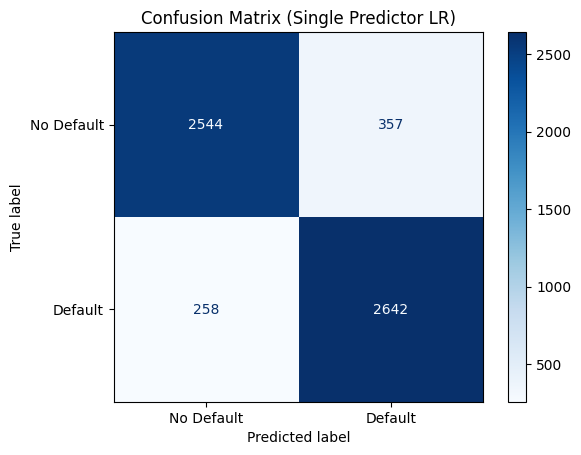

In [15]:
evaluate_model(single_predictor_logistic_model, X_test_balance_scaled, y_test, "Single Predictor LR")

#### Multiple predictors

Now, we'll try fitting a logistic regression model on multiple predictors from our dataset - namely, $\text{balance}$, $\text{income}$, and $\text{student}$.

In [16]:
scaler_multi = StandardScaler()
X_train_multi_scaled = scaler_multi.fit_transform(X_train)
X_test_multi_scaled = scaler_multi.transform(X_test)

multiple_predictor_logistic_model = LogisticRegression(random_state=42)
multiple_predictor_logistic_model.fit(X_train_multi_scaled, y_train)

feature_names = ['balance', 'income', 'student']
multiple_predictor_intercept = multiple_predictor_logistic_model.intercept_[0]
multiple_predictor_coefficients = multiple_predictor_logistic_model.coef_[0]

coef_table = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': multiple_predictor_coefficients
})

print("Multiple predictor logistic regression model (with scaled features):")
print(f"\\nIntercept: {multiple_predictor_intercept:.6f}")
print(coef_table)

Multiple predictor logistic regression model (with scaled features):
\nIntercept: -0.559512
   Feature  Coefficient
0  balance    -0.627099
1   income     4.241264
2  student    -0.130110


This time, our logistic model has learned a $\beta_0$ of -0.55, and a coefficient for each of our predictors: An increase in $\text{income}$ or a decrease in $\text{balance}$ increases our probabilities of $\text{default}$, while the negative coefficient for the $\text{student}$ predictor means that students are actually less likely to default.


--- Multiple Predictors LR Evaluation ---
Classification Report:
              precision    recall  f1-score   support

  No Default       0.91      0.88      0.89      2901
     Default       0.88      0.91      0.90      2900

    accuracy                           0.90      5801
   macro avg       0.90      0.90      0.90      5801
weighted avg       0.90      0.90      0.90      5801



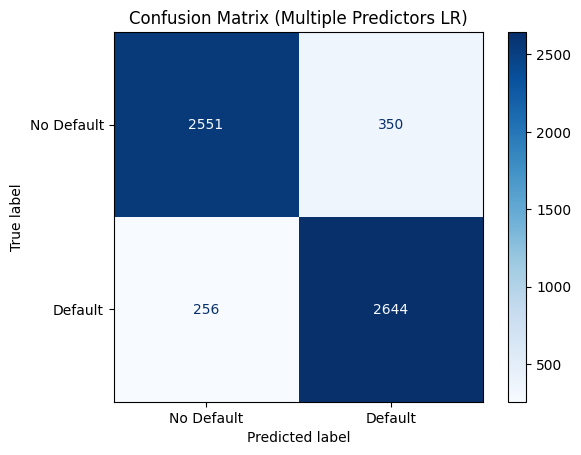

In [17]:
evaluate_model(multiple_predictor_logistic_model, X_test_multi_scaled, y_test, "Multiple Predictors LR")

### 3.4. Making & Visualizing Predictions with Logistic Regression

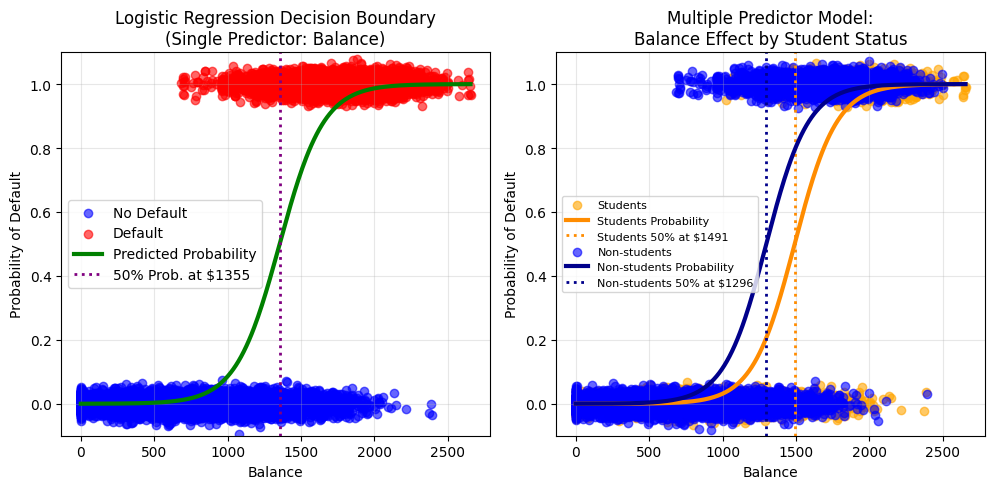

In [18]:
plt.figure(figsize=(15, 5))

# Plot 1: Single predictor model
plt.subplot(1, 3, 1)

balance_range = np.linspace(X_train_balance.min(), X_train_balance.max(), 300).reshape(-1, 1)
scaled_balance_range = scaler_balance.transform(balance_range)
probabilities = single_predictor_logistic_model.predict_proba(scaled_balance_range)[:, 1]

# Plot data points
for i, (color, label) in enumerate([('blue', 'No Default'), ('red', 'Default')]):
    mask = y_train == i
    plt.scatter(X_train_balance[mask], y_train[mask] + np.random.normal(0, 0.02, sum(mask)),
                c=color, alpha=0.6, label=label)

plt.plot(balance_range, probabilities, color='green', linewidth=3,
         label='Predicted Probability')

# Decision boundary
decision_boundary_balance = -single_predictor_intercept / single_predictor_coef
boundary_val = scaler_balance.inverse_transform([[decision_boundary_balance]])[0][0]
plt.axvline(x=boundary_val, color='purple', linestyle=':', linewidth=2,
            label=f'50% Prob. at ${boundary_val:.0f}')

plt.xlabel('Balance')
plt.ylabel('Probability of Default')
plt.title('Logistic Regression Decision Boundary\n(Single Predictor: Balance)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(-0.1, 1.1)

# Plot 2: Multiple predictor model by student status
plt.subplot(1, 3, 2)

mean_income = np.mean(X_train['income'])

# Generate probability curves for students and non-students
prob_curves = {}
for student_status, (color, label) in [(1, ('orange', 'Students')), (0, ('blue', 'Non-students'))]:
    X_pred = np.column_stack([np.full(300, student_status), balance_range, np.full(300, mean_income)])
    X_pred_scaled = scaler_multi.transform(X_pred)
    prob_curves[student_status] = multiple_predictor_logistic_model.predict_proba(X_pred_scaled)[:, 1]

    # Plot data points
    mask = X_train['student'] == student_status
    plt.scatter(X_train.loc[mask, 'balance'],
                y_train.loc[mask] + np.random.normal(0, 0.02, sum(mask)),
                alpha=0.6, color=color, label=label)

    # Plot probability curve
    dark_color = 'darkorange' if student_status == 1 else 'darkblue'
    plt.plot(balance_range, prob_curves[student_status], color=dark_color,
             linewidth=3, label=f'{label} Probability')

    # Decision boundary
    boundary_idx = np.argmin(np.abs(prob_curves[student_status] - 0.5))
    boundary_balance = balance_range[boundary_idx][0]
    plt.axvline(x=boundary_balance, color=dark_color, linestyle=':', linewidth=2,
                label=f'{label} 50% at ${boundary_balance:.0f}')

plt.xlabel('Balance')
plt.ylabel('Probability of Default')
plt.title('Multiple Predictor Model:\nBalance Effect by Student Status')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.ylim(-0.1, 1.1)

plt.tight_layout()
plt.show()

### 3.5 Logistic Regression for Multi-Class Classification

While Logistic Regression is inherently a binary classifier, it can be cleverly extended to handle problems with three or more classes. A common strategy is **One-vs-Rest (OvR)** classification, the default strategy used by `scikit-learn`. It's a straightforward and intuitive approach:
- **How it works:** For a dataset with *K* classes, you train *K* separate binary logistic regression models.

- **Training:** Model 1 is trained to distinguish Class 1 (positive) from all other classes (negative). Model 2 is trained to distinguish Class 2 (positive) from all others (negative), and so on.

- **Prediction:** When you want to classify a new data point, it's fed into all *K* models. Each model outputs a probability that the data point belongs to its "positive" class. The class corresponding to the model that outputs the highest probability is chosen as the final prediction.

Let's train a model on our synthetic 3-class dataset using the OvR strategy and visualize its decision boundaries.

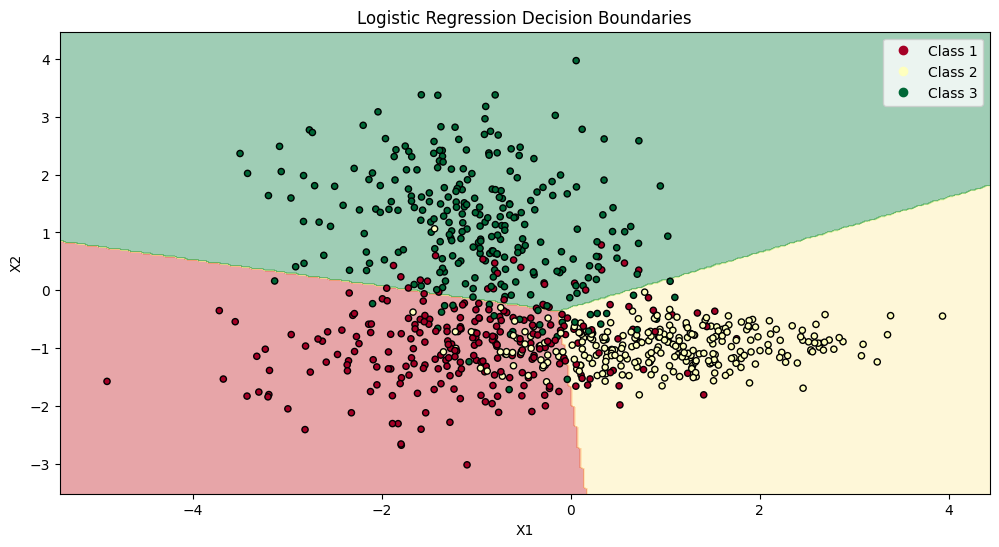

In [19]:
# Train a logistic regression model for multi-class classification
multi_class_lr = LogisticRegression(multi_class='ovr', random_state=42)
multi_class_lr.fit(X_train_multi, y_train_multi)

# Plot the decision boundaries
plot_decision_boundaries(X_train_multi, y_train_multi, multi_class_lr, "Logistic Regression Decision Boundaries", x1_padding=0.5, x2_padding=0.5)
plt.show()


--- Multi-Class Logistic Regression Evaluation ---
Classification Report:
              precision    recall  f1-score   support

     Class 1       0.86      0.78      0.82        77
     Class 2       0.79      0.90      0.84        62
     Class 3       0.88      0.85      0.87        61

    accuracy                           0.84       200
   macro avg       0.84      0.84      0.84       200
weighted avg       0.84      0.84      0.84       200



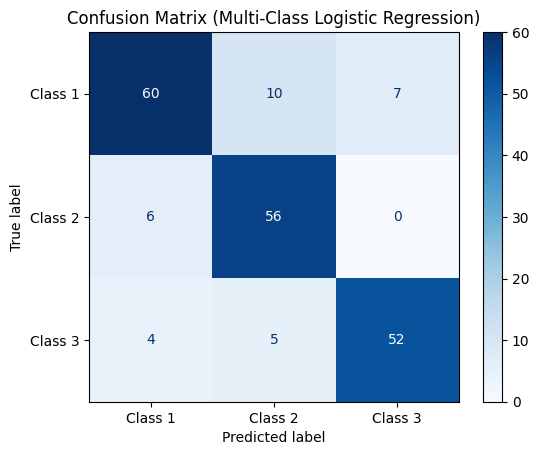

In [20]:
evaluate_model(multi_class_lr, X_test_multi, y_test_multi, "Multi-Class Logistic Regression", class_names=['Class 1', 'Class 2', 'Class 3'])

## 4. Decision Trees

### 4.1. Definition

Decision trees are one of the most intuitive machine learning algorithms for classification. They work by recursively partitioning the feature space into regions, where each partition corresponds to a decision based on a feature value.

Imagine you're trying to classify whether a credit card customer will default. A decision tree might first ask: "Is the customer's balance greater than $1500?" If yes, it goes to one branch; if no, it goes to another. Each branch continues to split until we reach a final decision about default status.

This recursive partitioning creates a tree-like structure where:
- **Internal nodes** represent decisions based on features

- **Branches** represent the outcomes of those decisions

- **Leaf nodes** represent the final classification

The key insight is that decision trees mimic human decision-making processes, making them highly interpretable compared to other models.


### 4.2. How Decision Trees Work: Recursive Partitioning


Decision trees use a concept called **recursive partitioning** to create homogeneous groups (or regions) in the feature space. The algorithm works as follows:

1. **Start with the entire dataset** at the root node

2. **Choose the best feature** to split the data (we'll discuss how to measure "best" shortly)

3. **Split the data** into subsets based on that feature

4. **Repeat the process** recursively on each subset

5. **Stop when** a stopping criterion is met (e.g., all instances in a node belong to the same class)

The goal is to create regions where the majority of instances belong to the same class. For example, we might end up with regions like:
- "High balance AND low income → Likely to default"

- "Low balance AND high income → Unlikely to default"

<img src="https://lh7-rt.googleusercontent.com/docsz/AD_4nXd2tu7KRpHf2ZR_F-Sg9THDDChlKOzKwsYZz_EdYXJZYcbJ1jrGPF0YtR9shdod1UmgyhblP-SyihTrHtr2qf2OuLVkXQkClFgk2TLKLfiRoomDIel6uFS5bH05fI8SwBrqP4A48TxX3ryb5pu6zG9FlmGo?key=xOxyNVf2yllNSdFKBNOlBA" width="700px">

### 4.3. Measuring Split Quality: Gini Impurity and Entropy

To decide where to split, we need a way to measure how "pure" a region is. There are two main measures:

**Gini Impurity** measures the probability of misclassifying a randomly chosen instance from the region:

$$Gini = 1 - \sum_{i=1}^c p_i^2$$

where $c$ is the number of classes and $p_i$ is the proportion of instances of class $i$.

For a binary classification with classes 0 and 1:
- If a node is pure (all instances are class 0): $Gini = 1 - (1² + 0²) = 0$

- If a node is evenly split: $Gini = 1 - (0.5² + 0.5²) = 0.5$

Gini impurities are used to evaluate branches after splitting. If both branches of a tree have an impurity of 0, then the decision tree managed to find the **perfect split** - all elements in branch A are of class X, and all elements in branch B are of class Y.

**Information Entropy** measures the disorder or uncertainty in a region. It can also be thought as the **variance of the data**. For example, a dataset of only one class would have zero entropy. In contrast, a dataset with multiple classes would have a relatively high entropy. The entropy for a dataset with $c$ classes is calculated like so:

$$Entropy = -\sum_{i=1}^c p_i \log_2 p_i$$

where $p_i$ is the probability of randomly picking an element of class $i$ (i.e. the proportion of the dataset made up of class $i$).

For a binary classification with classes 0 and 1:
- Pure node (all instances are class 0): $Entropy = -(1 * log_{2}1 + 0 * log_{2}0) = -(1 * 0 + 0) = -0 = 0$

- Evenly split: $Entropy = -(0.5 * log_{2}0.5 + 0.5 * log_{2}0.5) = -(0.5 * -1 + 0.5 * -1) = -(-1) = 1$

Both measures help us choose splits that create the most homogeneous child nodes - namely, splits with the lowest Gini impurities and lowest information entropy.

### 4.4. Building a Decision Tree Model

In [21]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [22]:
from sklearn.metrics import accuracy_score

# Create and fit the decision tree
# We'll use a max_depth of 5 for a balance between performance and interpretability
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)


--- Decision Tree (max depth = 5) Evaluation ---
Classification Report:
              precision    recall  f1-score   support

  No Default       0.91      0.89      0.90      2901
     Default       0.89      0.91      0.90      2900

    accuracy                           0.90      5801
   macro avg       0.90      0.90      0.90      5801
weighted avg       0.90      0.90      0.90      5801



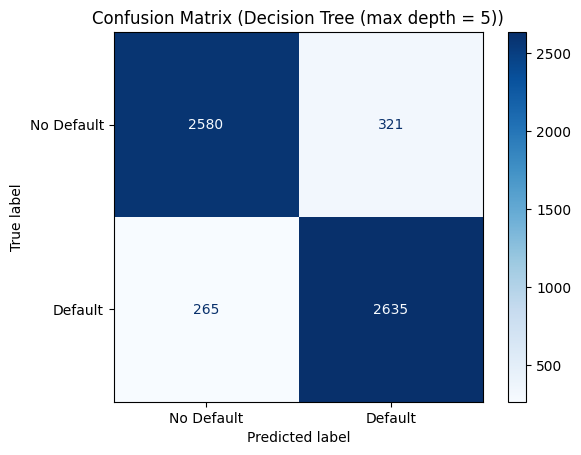

In [23]:
evaluate_model(dt_model, X_test, y_test, "Decision Tree (max depth = 5)", class_names=['No Default', 'Default'])

### 4.5. Visualizing the Decision Tree Structure

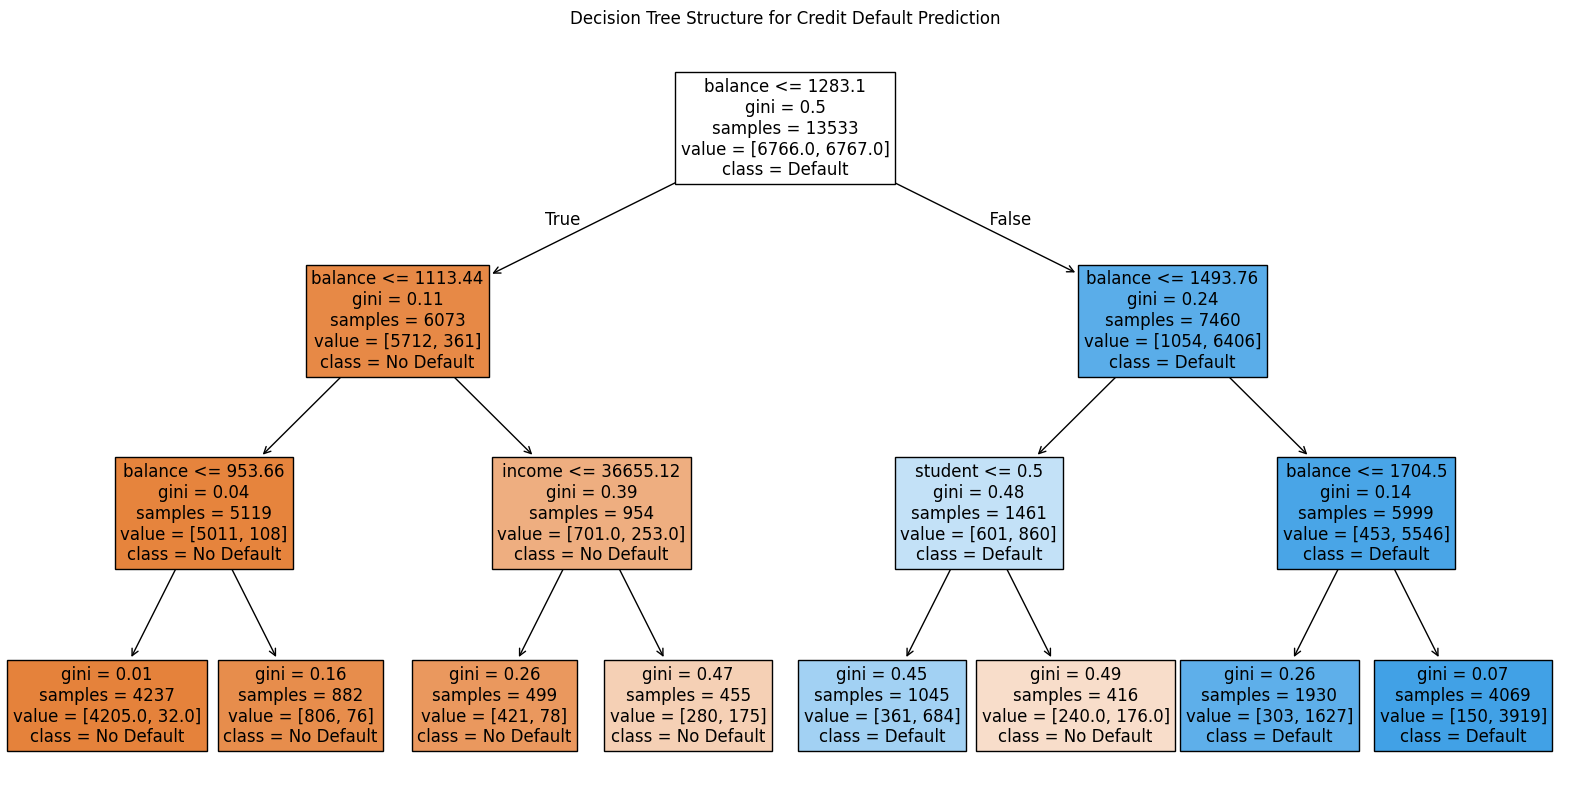

In [24]:
%matplotlib inline

dt_model = DecisionTreeClassifier(random_state=42, max_depth=3) # small depth for easier visualization
dt_model.fit(X_train, y_train)

plt.figure(figsize=(20, 10))
plot_tree(dt_model,
          feature_names=['student', 'balance', 'income'],
          class_names=['No Default', 'Default'],
          filled=True,
          impurity=True,
          precision=2,
          fontsize=12)
plt.title("Decision Tree Structure for Credit Default Prediction")
plt.show()

### 4.6. Decision Boundaries: Visualizing How Decision Trees Partition Space

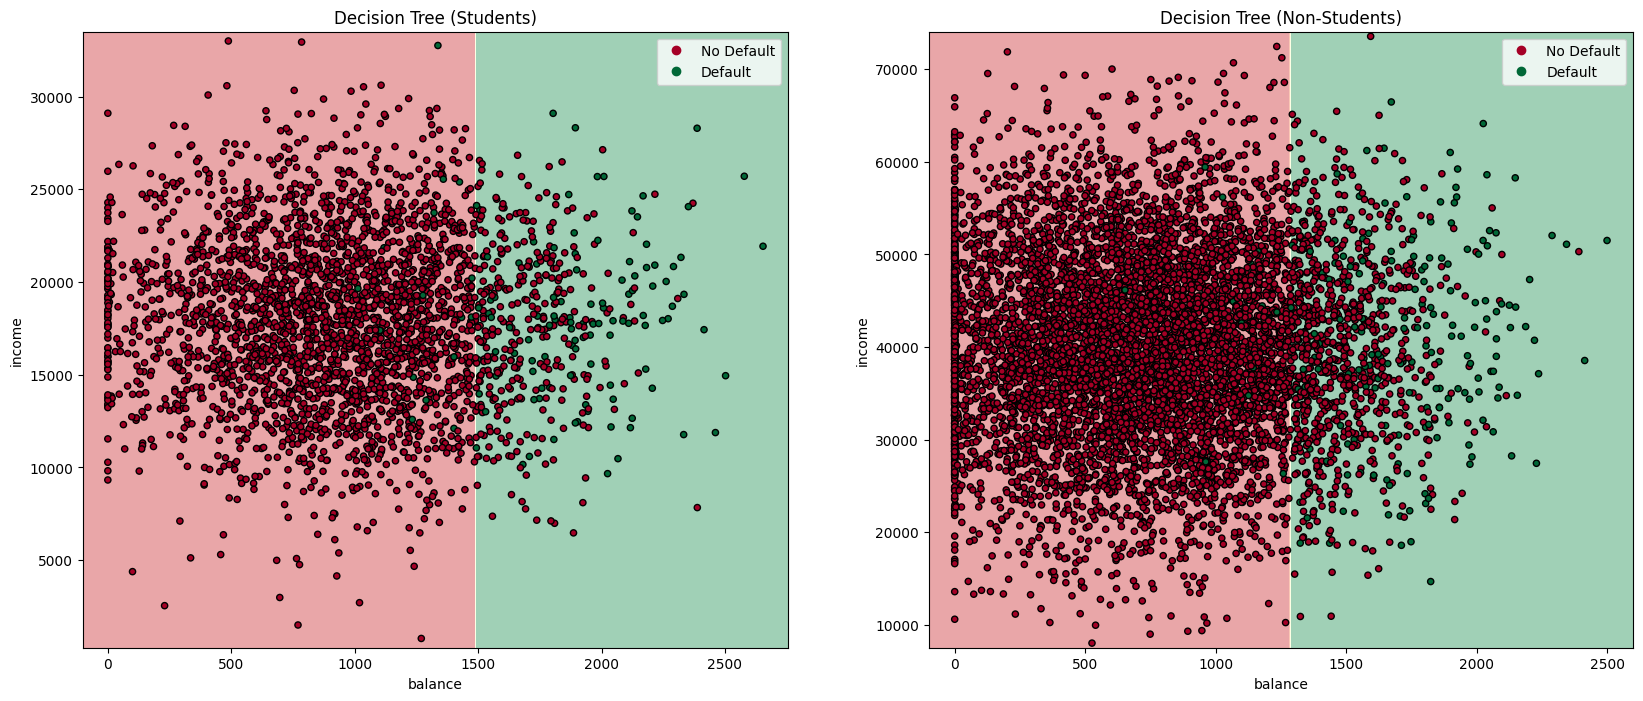

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

X_student = X[X['student'] == 1]
y_student = y[X['student'] == 1]
plot_decision_boundaries(X_student, y_student, dt_model, "Decision Tree (Students)",
                         feature_names=['balance', 'income'], class_names=['No Default', 'Default'], control_column='student', control_value=1,
                         ax=axes[0], x1_padding=100, x2_padding=500)

X_non_student = X[X['student'] == 0]
y_non_student = y[X['student'] == 0]
plot_decision_boundaries(X_non_student, y_non_student, dt_model, "Decision Tree (Non-Students)",
                         feature_names=['balance', 'income'], class_names=['No Default', 'Default'], control_column='student', control_value=0,
                         ax=axes[1], x1_padding=100, x2_padding=500)
plt.show()

### 4.7. Multi-Class Classification with Decision Trees

One advantage of decision trees is that they extend out-of-the-box for multi-class classification, as the core mechanism doesn't inherently care if there are 2 or 20 classes. At each split, the algorithm evaluates impurity reduction across all classes:

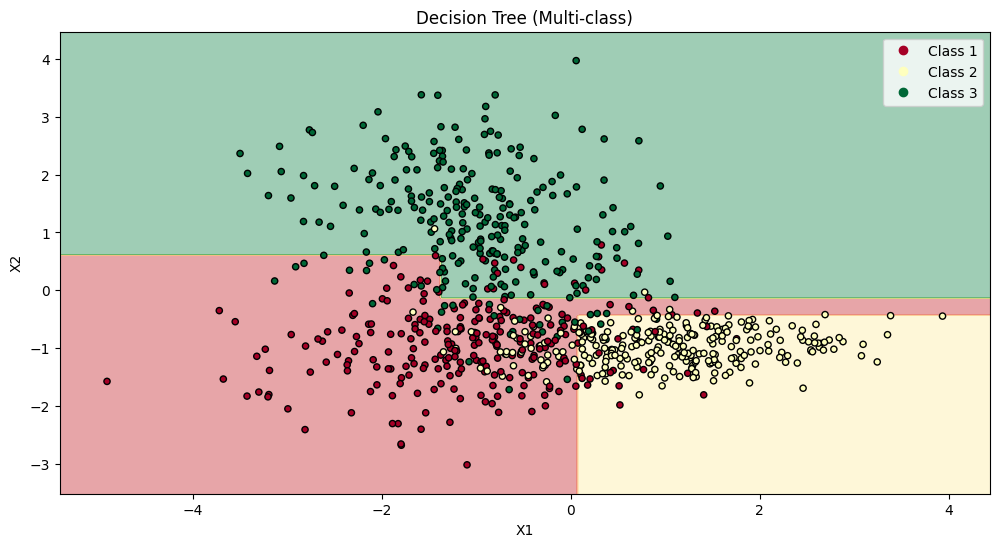

In [26]:
multi_class_dt = DecisionTreeClassifier(random_state=42, max_depth=3)
multi_class_dt.fit(X_train_multi, y_train_multi)

y_pred_multiclass_dt = multi_class_dt.predict(X_test_multi)
y_prob_multiclass_dt = multi_class_dt.predict_proba(X_test_multi)

plot_decision_boundaries(X_train_multi, y_train_multi, multi_class_dt, "Decision Tree (Multi-class)", x1_padding=0.5, x2_padding=0.5)
plt.show()


--- Decision Tree (Multi-class) Evaluation ---
Classification Report:
              precision    recall  f1-score   support

     Class 1       0.77      0.88      0.82        77
     Class 2       0.88      0.82      0.85        62
     Class 3       0.91      0.80      0.85        61

    accuracy                           0.84       200
   macro avg       0.85      0.84      0.84       200
weighted avg       0.85      0.84      0.84       200



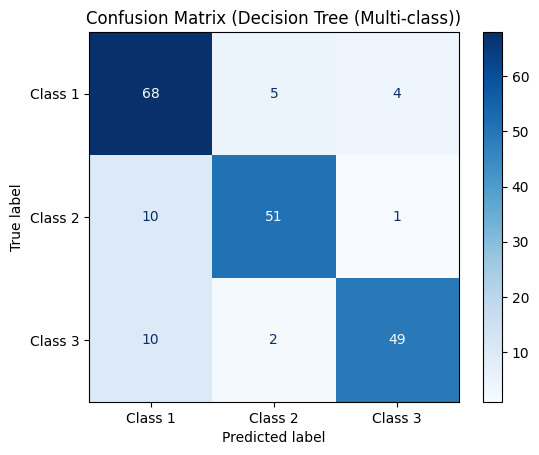

In [27]:
evaluate_model(multi_class_dt, X_test_multi, y_test_multi, "Decision Tree (Multi-class)", class_names=['Class 1', 'Class 2', 'Class 3'])

## 5. Random Forests

### 5.1. Definition and Ensemble Learning

Random forests are an **ensemble learning method** that combines multiple decision trees to create a more robust and accurate model. The key insight is that by combining many "weak learners" (individual decision trees), we can create a "strong learner" that performs better than any single tree.

**Ensemble learning** works on the principle that many weak models, when combined properly, can outperform strong individual models. This is similar to how a group of diverse experts can make better decisions than a single expert.

Random forests use a technique called **bagging** (bootstrap aggregating) combined with random feature selection to create diverse trees that, when combined, produce better predictions.

<img src="https://datasciencedojo.com/wp-content/uploads/random-forest-algorithm-random-forest.webp" width="500px">

### 5.2. How Random Forests Work: Bagging and Random Feature Selection

**Step 1: Bootstrap Sampling**
- Randomly sample the training data with replacement

- One can show that on average, each bagged tree makes use of around two-thirds of the observation

- The remaining third of the observations not used to fit a given bagged tree (out-of-bag samples) can be used for validation

**Step 2: Random Feature Selection**
- Each split considered for a given tree can only use a predictor from a random sample taken from the full set of predictors

- This ensures trees are diverse and don't all focus on the same strong features - this process can be seen as **decorrelating** the trees

- Typically, we select $\sqrt{\text{total features}}$ predictors for classification problems

**Step 3: Tree Construction**
- Build a full decision tree on each bootstrap sample

- Use only the randomly selected features at each split

- No pruning is typically done - trees are grown to full depth

**Step 4: Prediction**
- Each tree "votes" and the majority label wins

### 5.3. Building a Random Forest Model

In [28]:
from sklearn.ensemble import RandomForestClassifier

In [29]:
# Create and fit random forest
rf_model = RandomForestClassifier(
    n_estimators=100,      # Number of trees
    random_state=42,
    max_depth=None,        # Let trees grow fully
    min_samples_split=2,
    min_samples_leaf=1,
    bootstrap=True         # Use bootstrap sampling
)

# We'll reuse the same train/test split from the decision tree
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)


--- Random Forest (100 trees) Evaluation ---
Classification Report:
              precision    recall  f1-score   support

  No Default       0.94      0.90      0.92      2901
     Default       0.90      0.95      0.92      2900

    accuracy                           0.92      5801
   macro avg       0.92      0.92      0.92      5801
weighted avg       0.92      0.92      0.92      5801



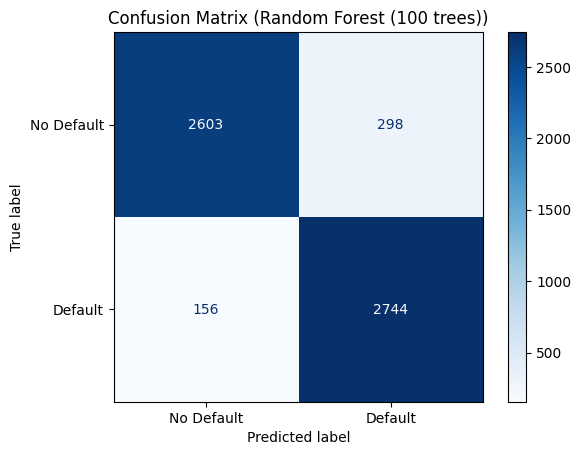

In [30]:
evaluate_model(rf_model, X_test, y_test, "Random Forest (100 trees)", class_names=['No Default', 'Default'])

### 5.4. Visualizing Random Forest Decision Boundaries

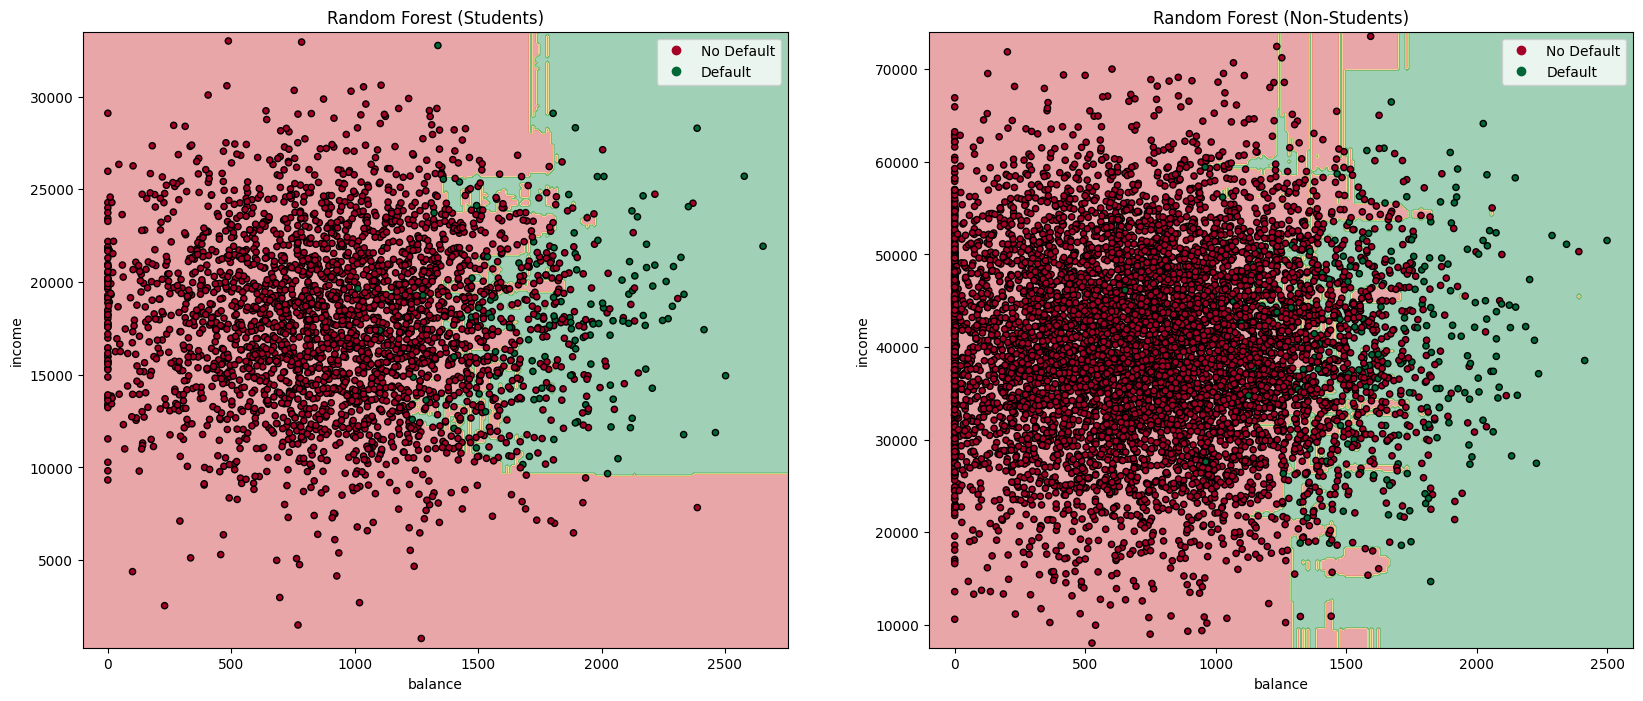

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

X_students = X[X['student'] == 1]
y_students = y[X['student'] == 1]
plot_decision_boundaries(X_students, y_students, rf_model, "Random Forest (Students)",
                         feature_names=['balance', 'income'], class_names=['No Default', 'Default'], control_column='student', control_value=1,
                         ax=axes[0], x1_padding=100, x2_padding=500)

X_non_students = X[X['student'] == 0]
y_non_students = y[X['student'] == 0]
plot_decision_boundaries(X_non_students, y_non_students, rf_model, "Random Forest (Non-Students)",
                         feature_names=['balance', 'income'], class_names=['No Default', 'Default'], control_column='student', control_value=0,
                         ax=axes[1], x1_padding=100, x2_padding=500)
plt.show()

Notice how the random forest creates smoother, less rigid decision boundaries compared to the single decision tree.

### 5.5. Multi-Class Classification with Random Forests

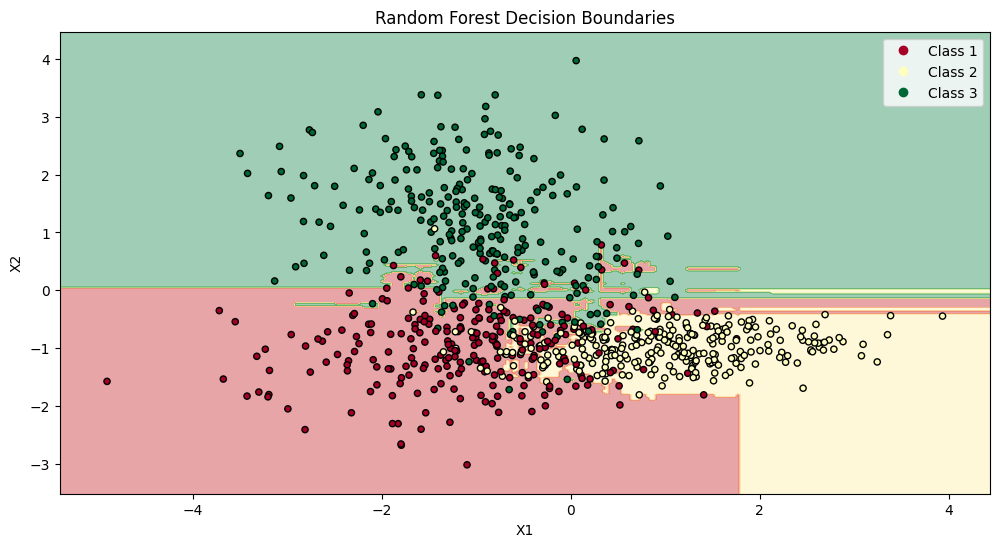

In [32]:
multi_rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    bootstrap=True
)

multi_rf_model.fit(X_train_multi, y_train_multi)

y_pred_multiclass_rf = multi_rf_model.predict(X_test_multi)
y_prob_multiclass_rf = multi_rf_model.predict_proba(X_test_multi)

plot_decision_boundaries(X_train_multi, y_train_multi, multi_rf_model, "Random Forest Decision Boundaries", x1_padding=0.5, x2_padding=0.5)
plt.show()


--- Random Forest Decision Boundaries Evaluation ---
Classification Report:
              precision    recall  f1-score   support

     Class 1       0.84      0.81      0.82        77
     Class 2       0.82      0.90      0.86        62
     Class 3       0.90      0.85      0.87        61

    accuracy                           0.85       200
   macro avg       0.85      0.85      0.85       200
weighted avg       0.85      0.85      0.85       200



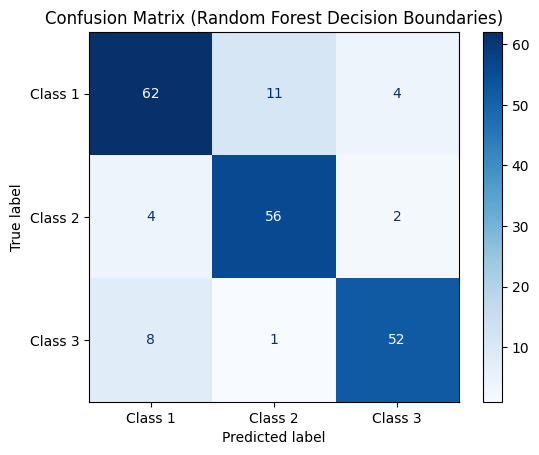

In [33]:
evaluate_model(multi_rf_model, X_test_multi, y_test_multi, "Random Forest Decision Boundaries", class_names=['Class 1', 'Class 2', 'Class 3'])

## 6. Support Vector Machines (SVMs)

### 6.1. Definition and Geometric Intuition

Support Vector Machines (SVMs) are powerful classification algorithms that work by finding the optimal **decision boundary** that maximally separates classes in the feature space. They use **hyperplanes** for determining these decision boundaries.

In a $p$-dimensional space, a hyperplane is a flat subspace of dimension $p-1$. For instance, in 2D, a hyperplane is a line; in 3D, it is a plane; for 4D and above, it's hard to visualize a hyperplane, but the notion still applies. In the following discussion, we'll talk about a line.

The key intuition behind SVMs is **maximal margin classification**:
- Instead of just finding any line that separates the classes, SVMs find the line that leaves the maximum "margin" or buffer zone around it

- This margin helps ensure good generalization to new data points

- Data points that lie on the margin boundaries are called **support vectors**, and the line depends on them - if they were moved slightly, the hyperplane would move along with them

Think of it like this: If you were drawing a line to separate cats from dogs, you wouldn't just draw any separating line. You'd want to draw the line that gives you the most confidence, namely the one with the widest "no-man's land" between the classes.

<img src="https://www.ibm.com/content/dam/connectedassets-adobe-cms/worldwide-content/creative-assets/s-migr/ul/g/8f/27/3-1_svm_optimal-hyperplane_max-margin_support-vectors-2-1.png" width="850px">

### 6.2. Mathematical Formulation

A $p$-dimensional hyperplane is defined by the following equation:

$$\beta_0+\beta_1X_1+\beta_2X_2+...+\beta_pX_p=0$$

where if a point $X=(X_1,X_2,...,X_p)^T$ in $p$-dimensional space satisfies the equation from above, it lies on the hyperplane. If it doesn't satisfy the equation, however, then it must be sitting on one side or the other. We can use the sign to thus classify $p$-dimensional points - those for which the equation result is $<0$ belong to one half, and those for which it is $>0$ belong to the other.

$$
\text{Classification} = \begin{cases}
\text{Class A} & \text{if } \beta_0 + \beta_1X_1 + \beta_2X_2 + \ldots + \beta_pX_p > 0 \\
\text{Class B} & \text{if } \beta_0 + \beta_1X_1 + \beta_2X_2 + \ldots + \beta_pX_p < 0
\end{cases}
$$

**The Optimization Problem:**

SVMs solve the following optimization problem:

$$\max_{\beta, \beta_0, \epsilon, M} M$$

$$\text{subject to} \sum_{j=1}^{p}\beta_{j}^{2} = 1,$$
$$y_i(\beta_0+\beta_1x_{i1}+\beta_2x_{i2}+...+\beta_px_{ip})\geq M(1-\epsilon_{i}),$$
$$\epsilon_{i}\geq 0, \sum_{i=1}^{n}{\epsilon_{i}}\leq C,$$

where:
- $\beta_0$ is the intercept (bias)
- $\beta$ are the coefficients (weights). The first constraint ensures that **we maximize the margin size without "cheating" by scaling it along with the weights**
- $x_i$ are the feature vectors
- $y_i$ are the class labels (+1 or -1)
- $M$ is the width of the margin - we seek to make this quantity **as large as possible**
- $C$ is a non-negative tuning parameter
- $\epsilon_{1}, ..., \epsilon_{n}$ are **_slack variables_** that allows individual observations to be on the wrong side of the margin or the hyperplane.

In practice, $C$ is treated as a tuning parameter that is generally chosen via cross-validation. When $C$ is small, we seek narrow margins that are rarely violated and have fewer support vectors; this amounts to a classifier that is highly fit to the data. On the other hand, a larger $C$ leads to a wider margin, which allows more violations to it and has many support vectors, thus obtaining a classifier that fits the data less.

The figure below shows how the margin changes with varying C values. The largest value of C, used in the top left panel, results in the widest margins, which tolerate many observations on the wrong side of them. On the other hand, as C decreases, the margin narrows.

<img src="https://cambiotraining.github.io/intro-machine-learning/images/svm.9.7.png" width="700px">

### 6.3. The Kernel Trick: Handling Non-Linear Boundaries

What if the classes aren't linearly separable? This is where SVMs become truly powerful through the use of **kernels**. Let's understand this step by step.

**The Problem with Non-Linear Data:**

In many real-world scenarios, classes cannot be separated by a straight line (or hyperplane in higher dimensions). Imagine trying to separate two groups of points arranged in concentric circles - no straight line could ever separate them properly.

**The Solution: Feature Space Transformation**
The key insight is that data that isn't linearly separable in its original space might become linearly separable if we transform it to a higher-dimensional space. The figure below illustrates an example:
- If we have data points $(x_1, x_2)$ in 2D that form concentric circles
- We could transform them to 3D using features like $(x_1, x_2, x_1^2 + x_2^2)$
- In this new 3D space, the circles become separable by a plane!

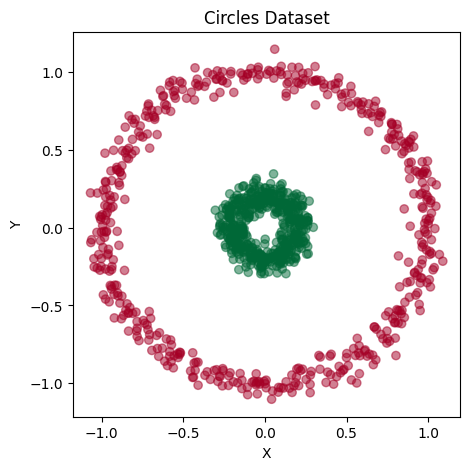

In [34]:
%matplotlib inline

from sklearn.datasets import make_circles

circles = make_circles(n_samples=1000, noise=0.05, factor=0.2)

circles_X = circles[0]
circles_y = circles[1]

plt.figure(figsize=(5, 5))
plt.scatter(circles_X[:, 0], circles_X[:, 1], c=circles_y, cmap='RdYlGn', alpha=0.5)
plt.title('Circles Dataset')
plt.xlabel('X')
plt.ylabel('Y')

plt.show()

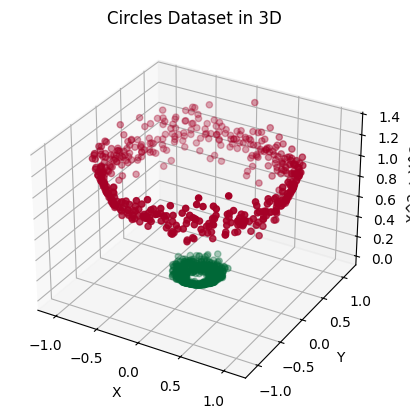

In [35]:
transformed_X1 = circles_X[:, 0].reshape(-1, 1)
transformed_X2 = circles_X[:, 1].reshape(-1, 1)
transformed_X3 = transformed_X1 ** 2 + transformed_X2 ** 2
transformed_X = np.hstack((transformed_X1, transformed_X2, transformed_X3))

ax = plt.figure().add_subplot(projection='3d')
ax.scatter(transformed_X[:, 0], transformed_X[:, 1], transformed_X[:, 2], c=circles_y, cmap='RdYlGn')
ax.set_title('Circles Dataset in 3D')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('X^2 + Y^2')

plt.show()

**The Kernel Trick:**
The SVM optimization can be reformulated in such a way that it only depends on **inner products between data points**. Here's the brilliant insight: if SVM only needs inner products, and we want to work in a transformed feature space $\phi(x)$, we can create a special function (called a **kernel**) that directly computes the inner product in the transformed space: $K(x_i, x_j) = \phi(x_i) \cdot \phi(x_j)$.

This means:
 - We get the power of complex feature transformations
 - Without the computational cost of actually creating those features
 - We only compute what SVM actually needs (the inner products)
 - The optimization problem remains exactly the same, just with $K(x_i, x_j)$ replacing $x_i \cdot x_j$

 **Common Kernels:**

 1. **Linear Kernel**: $K(x_i, x_j) = x_i^T x_j$
    - No transformation - just the original inner product
    - For data that's already linearly separable

 2. **Polynomial Kernel**: $K(x_i, x_j) = (x_i^T x_j + c)^d$
    - Creates curved decision boundaries
    - Good for moderately complex patterns

 3. **RBF (Radial Basis Function) Kernel**: $K(x_i, x_j) = exp(-\gamma ||x_i - x_j||^2)$
    - Most popular choice
    - Can handle very complex, wiggly decision boundaries
    - The $\gamma$ parameter controls how "tight" the decision boundary is

 **The Bottom Line:**
 Kernels allow SVMs to find complex decision boundaries while keeping the math tractable. The key insight is that the SVM optimization problem naturally reduces to computing inner products, and kernels let us compute these inner products in transformed spaces without explicitly creating the transformations.

### 6.4. Building an SVM

In [36]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# SVMs are sensitive to feature scales, so we'll standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# We'll use the RBF kernel, which is a good default
svm_model = SVC(kernel='rbf', C=1.0, random_state=42, probability=True)
svm_model.fit(X_train_scaled, y_train)

SVC(probability=True, random_state=42)


--- SVM (RBF) Evaluation ---
Classification Report:
              precision    recall  f1-score   support

  No Default       0.93      0.86      0.89      2901
     Default       0.87      0.94      0.90      2900

    accuracy                           0.90      5801
   macro avg       0.90      0.90      0.90      5801
weighted avg       0.90      0.90      0.90      5801



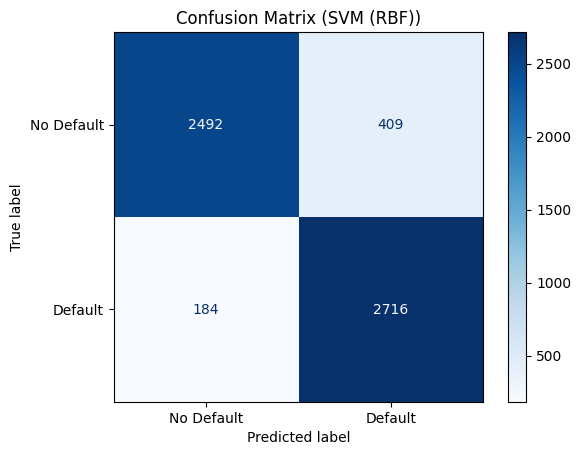

In [37]:
evaluate_model(svm_model, X_test_scaled, y_test, "SVM (RBF)")

### 6.5. Visualizing SVM Decision Boundaries

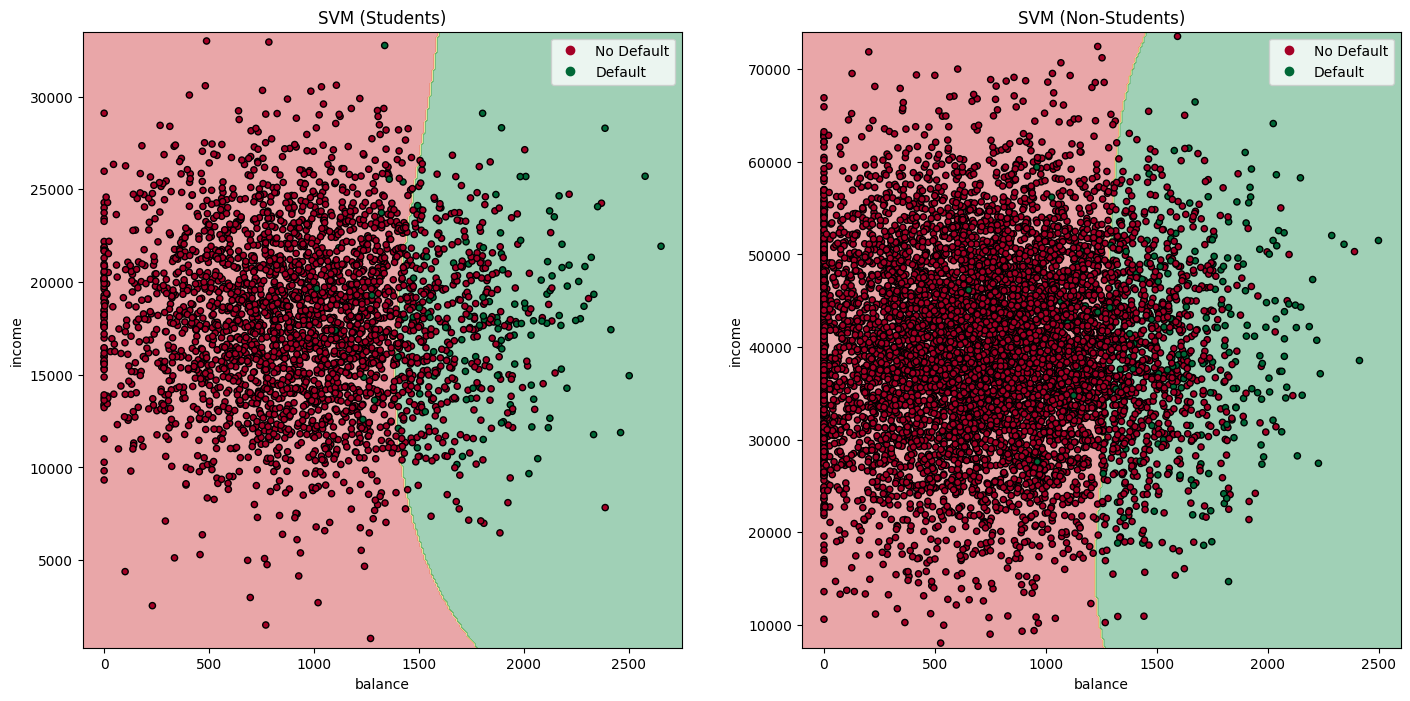

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(17, 8))

X_students = X[X['student'] == 1]
y_students = y[X['student'] == 1]
plot_decision_boundaries(X_students, y_students, svm_model, "SVM (Students)",
                         feature_names=['balance', 'income'], class_names=['No Default', 'Default'],
                         control_column='student', control_value=1,
                         ax=axes[0], X_scaler=scaler_multi, x1_padding=100, x2_padding=500)

X_non_students = X[X['student'] == 0]
y_non_students = y[X['student'] == 0]
plot_decision_boundaries(X_non_students, y_non_students, svm_model, "SVM (Non-Students)",
                         feature_names=['balance', 'income'], class_names=['No Default', 'Default'],
                         control_column='student', control_value=0,
                         ax=axes[1], X_scaler=scaler_multi, x1_padding=100, x2_padding=500)

plt.show()

### 6.6. Multi-Class Classification with SVMs

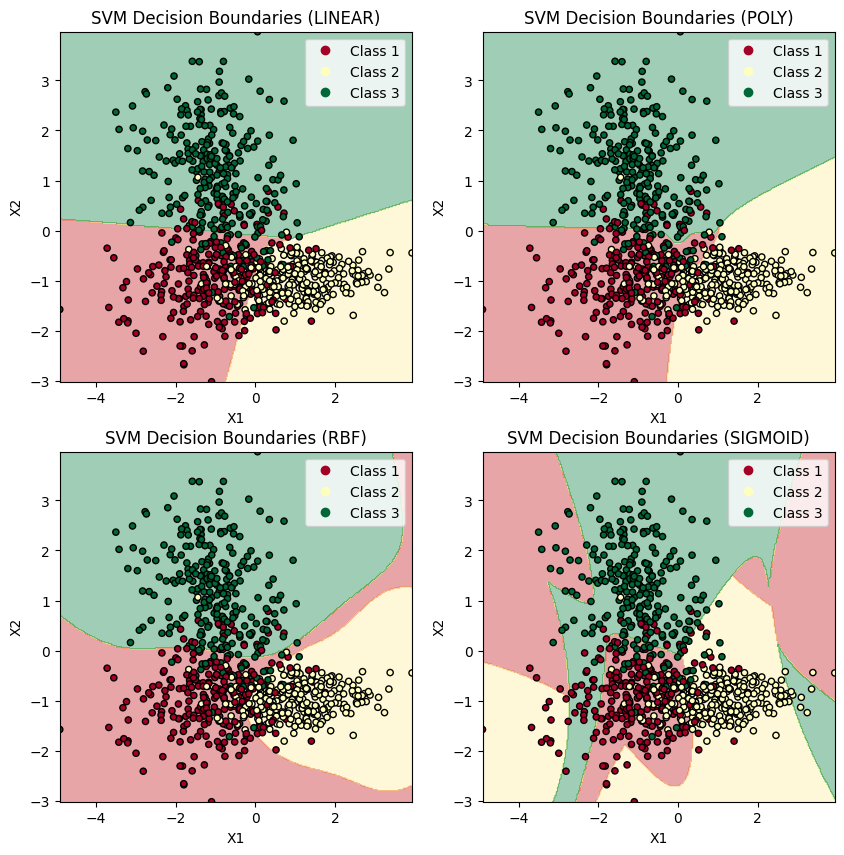

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for i, kernel in enumerate(['linear', 'poly', 'rbf', 'sigmoid']):
    ax = axes[i // 2, i % 2]

    multi_svm_model = SVC(kernel=kernel, C=1.0, random_state=1, probability=True)
    multi_svm_model.fit(X_train_multi, y_train_multi)

    y_pred_multiclass_svm = multi_svm_model.predict(X_test_multi)
    y_prob_multiclass_svm = multi_svm_model.predict_proba(X_test_multi)

    plot_decision_boundaries(X_train_multi, y_train_multi, multi_svm_model, f"SVM Decision Boundaries ({kernel.upper()})", ax=ax)

plt.show()

## 7. Summary: Choosing the Right Classification Method

Now that we've explored four major classification algorithms, let's discuss how to choose the right one for your problem.

**Algorithm Strengths:**
- **Logistic Regression**: Fast, interpretable baseline - works well for linear relationships

- **Decision Trees**: Most interpretable - perfect when you need to explain exact decision paths

- **Random Forests**: Best performance with interpretability - provides feature importance insights

- **SVMs**: Best for high-dimensional data and complex non-linear patterns

**Key Considerations:**
- **Dataset size**: SVMs struggle with very large datasets, trees handle any size well

- **Interpretability**: Trees > Logistic Regression > Random Forests > SVMs

- **Feature scaling**: Required for Logistic Regression and SVMs, not needed for tree methods

- **Performance**: Random Forests often perform best, followed by SVMs for complex data

**Practical Approach:**
- Start with **Logistic Regression** as your baseline

- Try **Random Forests** for better performance

- Use **Decision Trees** when interpretability is critical

- Consider **SVMs** for high-dimensional or complex pattern data

- Always compare multiple methods on your specific dataset to find the best fit

## 8. Assignment: Heart Disease Classification Challenge

### **Objective**
Apply all four classification methods we've learned to predict heart disease using a real medical dataset. Compare their performance and analyze which method works best for this healthcare application.

### **Dataset Overview**
You'll be working with the **Heart Disease UCI dataset** containing 13 clinical features to predict whether a patient has heart disease:

**Clinical Features:**
- **age**: Patient's age in years

- **sex**: Gender (Male/Female)

- **cp**: Chest pain type (typical angina, atypical angina, non-anginal, asymptomatic)

- **trestbps**: Resting blood pressure (mm Hg)

- **chol**: Serum cholesterol (mg/dl)

- **fbs**: Fasting blood sugar > 120 mg/dl (True/False)

- **restecg**: Resting electrocardiographic results

- **thalch**: Maximum heart rate achieved

- **exang**: Exercise induced angina (True/False)

- **oldpeak**: ST depression induced by exercise relative to rest

- **slope**: Slope of the peak exercise ST segment

- **ca**: Number of major vessels colored by fluoroscopy (0-3)

- **thal**: Thalassemia (normal, fixed defect, reversable defect)

**Target Variable:**
- **num**: Heart disease status (0 = healthy, 1 = has heart disease)

### **Assignment Tasks**
Complete the following tasks in order. Each task builds upon the previous ones:

**1. Data Exploration & Preprocessing**
- Load and examine the dataset structure

- Check for missing values and handle them appropriately

- Perform exploratory data analysis with at least 3 visualizations

- Potentially create new useful features

- Encode categorical variables (sex, cp, restecg, slope, thal)

- Split data into training and testing sets (80/20 split)

**2. Feature Analysis**
- Create correlation matrix heatmap to identify relationships

- Analyze class distribution (healthy vs. heart disease)

- Scale features for algorithms that require it

**3. Model Implementation**
Implement and train all four classification methods:
- **Logistic Regression**

- **Decision Tree**: Tune max_depth and min_samples_split

- **Random Forest**: Tune n_estimators and max_depth

- **Support Vector Machine**: Try both linear and RBF kernels, tune C

**4. Model Evaluation**
For each model, calculate and compare:
- Accuracy

- Confusion matrices

- Summarize results in a comparison table

### **Tips for Success**

**Data Preprocessing Tips:**
- Use `pd.get_dummies()` for categorical encoding

- Check for outliers in continuous variables

- Consider using `StandardScaler` for Logistic Regression and SVM

**Model Training Tips:**
- Start with default parameters, then tune systematically

- Use `train_test_split(stratify=y)` to maintain class balance

- Set `random_state=42` for reproducible results

In [40]:
# Download latest version
path = kagglehub.dataset_download("redwankarimsony/heart-disease-data")
dataset_path = "/".join((path, "heart_disease_uci.csv"))

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'heart-disease-data' dataset.
Path to dataset files: /kaggle/input/heart-disease-data


In [41]:
dataset = pd.read_csv(dataset_path)
dataset['num'] = dataset['num'].apply(lambda x: 1 if x > 0 else 0)

dataset.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,1
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
